In [1]:
# If needed (uncomment):
!pip -q install opencv-python tqdm scikit-learn qwen_vl_utils

In [2]:
from pathlib import Path

# === CHANGE THESE ===
VIDEOS_DIR = Path("/content/datasetme")

In [3]:
          # folder with your 220 videos
LABELS_CSV = Path("/content/labels.csv")       # must exist (template generator provided below)

# Output folders
FRAMES_DIR = Path("/content/frames")           # extracted frames go here
OUT_JSONL_TRAIN = Path("data/train.jsonl")
OUT_JSONL_VAL   = Path("data/val.jsonl")

# Sampling
NUM_FRAMES = 8          # how many frames per clip
RESIZE_W = 640          # resize width (keeps aspect ratio); set None to skip resizing

# Split
VAL_RATIO = 0.2
RANDOM_SEED = 42

# If your clips are always ~5 seconds, use that for metadata only (not mandatory)
CLIP_SECONDS = 5

print("VIDEOS_DIR:", VIDEOS_DIR.resolve())
print("LABELS_CSV:", LABELS_CSV.resolve())
print("FRAMES_DIR:", FRAMES_DIR.resolve())


VIDEOS_DIR: /content/datasetme
LABELS_CSV: /content/labels.csv
FRAMES_DIR: /content/frames


In [4]:

import csv
from pathlib import Path

def make_labels_template(videos_dir: Path, out_csv: Path):
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    video_files = sorted([p for p in videos_dir.glob("*") if p.suffix.lower() in [".mp4", ".avi", ".mov", ".mkv", ".webm"]])
    if not video_files:
        raise FileNotFoundError(f"No videos found in {videos_dir}. Put your videos there first.")
    with out_csv.open("w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=[
            "clip_id","video_path",
            "dominant_operation","start_frame","end_frame",
            "anticipated_next_operation","confidence"
        ])
        w.writeheader()
        for vp in video_files:
            clip_id = vp.stem
            w.writerow({
                "clip_id": clip_id,
                "video_path": str(vp),
                "dominant_operation": "",
                "start_frame": "",
                "end_frame": "",
                "anticipated_next_operation": "",
                "confidence": ""
            })
    print(f"Wrote template: {out_csv}  (rows={len(video_files)})")

# Uncomment to generate template:

make_labels_template(VIDEOS_DIR, LABELS_CSV)

Wrote template: /content/labels.csv  (rows=221)


## 2) (Optional) Create a labels.csv template
If you don't have `labels.csv` yet, run this to generate a template.

It will create columns:
- `clip_id` (defaults to video filename without extension)
- `video_path`
- `dominant_operation`
- `start_frame`, `end_frame` (1-based indices within the sampled frames)
- `anticipated_next_operation`
- `confidence`

Fill it and continue.

## 3) Define your system prompt & allowed operation labels
Replace `ALLOWED_LABELS` with your real operation set.

Tip: keep labels **exactly consistent** (no synonyms), otherwise the model will drift.

In [5]:

import json

# === PUT YOUR REAL LABELS HERE ===
ALLOWED_LABELS = ["Assemble Box", "Pick Cardboard", "Unknown"]

SYSTEM_PROMPT = (
    "You are a temporal warehouse operations classification model.\n\n"
    "Input: sampled video frames from a 5-second clip in chronological order.\n\n"
    "Task:\n"
    "1) Identify the dominant_operation (the single operation that occupies the largest portion of the clip).\n"
    "2) Provide the temporal segment (start_frame, end_frame) indicating where the dominant_operation is visible.\n"
    "3) Predict anticipated_next_operation (the most likely next operation immediately after the clip).\n"
    "4) Provide confidence as a float in [0.0, 1.0].\n\n"
    "Output rules (STRICT):\n"
    "- Output ONLY valid JSON. No markdown, no prose, no code fences, no extra keys.\n"
    "- Use exactly these top-level keys:\n"
    "  clip_id, dominant_operation, temporal_segment, anticipated_next_operation, confidence\n"
    "- temporal_segment must be an object with exactly:\n"
    "  start_frame, end_frame\n"
    "- start_frame and end_frame must be integers referencing the 1-based index of the provided frames (first frame = 1).\n"
    "- start_frame <= end_frame.\n"
    "- If the operation cannot be determined, set dominant_operation to \"Unknown\" and confidence <= 0.40.\n"
    f"- Use only allowed labels for operations: {json.dumps(ALLOWED_LABELS)}\n"
    "- anticipated_next_operation must be one of the allowed labels or \"Unknown\".\n"
    "- Confidence calibration:\n"
    "  0.90–1.00 = unmistakable cues across multiple frames\n"
    "  0.70–0.89 = clear but not perfect evidence\n"
    "  0.50–0.69 = plausible guess\n"
    "  0.00–0.49 = weak/ambiguous\n"
)

print(SYSTEM_PROMPT)


You are a temporal warehouse operations classification model.

Input: sampled video frames from a 5-second clip in chronological order.

Task:
1) Identify the dominant_operation (the single operation that occupies the largest portion of the clip).
2) Provide the temporal segment (start_frame, end_frame) indicating where the dominant_operation is visible.
3) Predict anticipated_next_operation (the most likely next operation immediately after the clip).
4) Provide confidence as a float in [0.0, 1.0].

Output rules (STRICT):
- Output ONLY valid JSON. No markdown, no prose, no code fences, no extra keys.
- Use exactly these top-level keys:
  clip_id, dominant_operation, temporal_segment, anticipated_next_operation, confidence
- temporal_segment must be an object with exactly:
  start_frame, end_frame
- start_frame and end_frame must be integers referencing the 1-based index of the provided frames (first frame = 1).
- start_frame <= end_frame.
- If the operation cannot be determined, set do

## 4) Extract sampled frames from each video
This samples **NUM_FRAMES** evenly across the clip and saves JPEGs.

It uses OpenCV for reliable frame indexing.

In [6]:

from pathlib import Path
from tqdm import tqdm
import cv2
import numpy as np

def sample_frame_indices(total_frames: int, num_samples: int):
    if total_frames <= 0:
        return []
    if num_samples <= 1:
        return [max(0, total_frames // 2)]
    return [int(round(x)) for x in np.linspace(0, total_frames - 1, num_samples)]

def extract_frames(video_path: Path, out_dir: Path, num_frames: int = 8, resize_w: int | None = 640):
    out_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Failed to open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs = sample_frame_indices(total_frames, num_frames)

    saved = []
    for i, frame_idx in enumerate(idxs, start=1):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = cap.read()
        if not ok or frame is None:
            continue
        if resize_w is not None:
            h, w = frame.shape[:2]
            new_w = int(resize_w)
            new_h = int(round(h * (new_w / w)))
            frame = cv2.resize(frame, (new_w, new_h), interpolation=cv2.INTER_AREA)

        out_path = out_dir / f"{i:06d}.jpg"
        cv2.imwrite(str(out_path), frame, [int(cv2.IMWRITE_JPEG_QUALITY), 92])
        saved.append(out_path)

    cap.release()
    return saved

print("Ready.")


Ready.


## 5) Build JSONL (chat format) from labels.csv
This will:
- extract frames for each row (if not already extracted)
- write `train.jsonl` and `val.jsonl`

### labels.csv requirements
Required columns:
- clip_id
- video_path
- dominant_operation
- start_frame, end_frame (1-based within the sampled frames)
- anticipated_next_operation
- confidence (0..1)


In [7]:

import csv
import json
from sklearn.model_selection import train_test_split

def read_labels_csv(path: Path):
    with path.open("r", newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    if not rows:
        raise ValueError("labels.csv is empty.")
    required = ["clip_id","video_path","dominant_operation","start_frame","end_frame","anticipated_next_operation","confidence"]
    for r in required:
        if r not in rows[0]:
            raise ValueError(f"labels.csv missing column: {r}")
    return rows

def build_sample(clip_id: str, frame_paths, dominant_op: str, start_f: int, end_f: int,
                 next_op: str, conf: float):
    user_content = [
        {"type":"text", "text": f"clip_id: {clip_id}\nClassify the clip. Return JSON only."}
    ]
    for p in frame_paths:
        user_content.append({"type":"image", "image": str(p)})

    assistant_obj = {
        "clip_id": clip_id,
        "dominant_operation": dominant_op,
        "temporal_segment": {"start_frame": start_f, "end_frame": end_f},
        "anticipated_next_operation": next_op,
        "confidence": float(conf),
    }

    return {
        "messages": [
            {"role":"system", "content": SYSTEM_PROMPT},
            {"role":"user", "content": user_content},
            {"role":"assistant", "content": json.dumps(assistant_obj, ensure_ascii=False)}
        ]
    }

def validate_row(row):
    dom = row["dominant_operation"].strip() or "Unknown"
    nxt = row["anticipated_next_operation"].strip() or "Unknown"

    if dom not in ALLOWED_LABELS:
        raise ValueError(f"dominant_operation '{dom}' not in ALLOWED_LABELS")
    if nxt not in ALLOWED_LABELS:
        raise ValueError(f"anticipated_next_operation '{nxt}' not in ALLOWED_LABELS")

    sf = int(row["start_frame"] or 1)
    ef = int(row["end_frame"] or NUM_FRAMES)
    if sf < 1 or ef < 1 or sf > ef:
        raise ValueError(f"Bad temporal segment: {sf}-{ef}")

    conf = float(row["confidence"] or (0.35 if dom == "Unknown" else 0.7))
    if conf < 0 or conf > 1:
        raise ValueError(f"confidence out of range: {conf}")

    return dom, nxt, sf, ef, conf

def build_jsonl(labels_csv: Path, videos_dir: Path, frames_dir: Path, out_train: Path, out_val: Path,
               num_frames: int, resize_w: int | None, val_ratio: float, seed: int):
    rows = read_labels_csv(labels_csv)

    # train/val split by clip_id
    clip_ids = [r["clip_id"] for r in rows]
    train_ids, val_ids = train_test_split(clip_ids, test_size=val_ratio, random_state=seed, shuffle=True)

    id_to_row = {r["clip_id"]: r for r in rows}

    def process_split(split_ids, out_path: Path):
        out_path.parent.mkdir(parents=True, exist_ok=True)
        with out_path.open("w", encoding="utf-8") as f:
            for cid in tqdm(split_ids, desc=f"Writing {out_path.name}"):
                r = id_to_row[cid]
                dom, nxt, sf, ef, conf = validate_row(r)

                video_path = Path(r["video_path"])
                if not video_path.is_absolute():
                    video_path = (videos_dir / video_path).resolve()

                clip_frame_dir = frames_dir / cid
                existing = sorted(clip_frame_dir.glob("*.jpg")) if clip_frame_dir.exists() else []
                if len(existing) < num_frames:
                    frame_paths = extract_frames(video_path, clip_frame_dir, num_frames=num_frames, resize_w=resize_w)
                else:
                    frame_paths = existing[:num_frames]

                if len(frame_paths) < num_frames:
                    raise RuntimeError(f"{cid}: only extracted {len(frame_paths)} frames (expected {num_frames})")

                if ef > len(frame_paths):
                    raise ValueError(f"{cid}: end_frame={ef} > extracted_frames={len(frame_paths)}")

                sample = build_sample(cid, frame_paths, dom, sf, ef, nxt, conf)
                f.write(json.dumps(sample, ensure_ascii=False) + "\n")

    process_split(train_ids, out_train)
    process_split(val_ids, out_val)

    print("✅ Done.")
    print("Train:", out_train)
    print("Val:  ", out_val)

# Run:
build_jsonl(LABELS_CSV, VIDEOS_DIR, FRAMES_DIR, OUT_JSONL_TRAIN, OUT_JSONL_VAL,
            num_frames=NUM_FRAMES, resize_w=RESIZE_W, val_ratio=VAL_RATIO, seed=RANDOM_SEED)


Writing val.jsonl: 100%|██████████| 45/45 [00:00<00:00, 3519.11it/s]

✅ Done.
Train: data/train.jsonl
Val:   data/val.jsonl


## 6) Sanity-check: load and print 1 JSONL row
This verifies the JSONL is valid and matches your schema.

In [8]:

import json
from itertools import islice
from pathlib import Path

def peek_jsonl(path: Path, n=1):
    with path.open("r", encoding="utf-8") as f:
        for line in islice(f, n):
            obj = json.loads(line)
            print(json.dumps(obj, indent=2, ensure_ascii=False)[:2500], "\n")

# After generating JSONL, run:


In [9]:
peek_jsonl(OUT_JSONL_TRAIN, n=1)

{
  "messages": [
    {
      "role": "system",
      "content": "You are a temporal warehouse operations classification model.\n\nInput: sampled video frames from a 5-second clip in chronological order.\n\nTask:\n1) Identify the dominant_operation (the single operation that occupies the largest portion of the clip).\n2) Provide the temporal segment (start_frame, end_frame) indicating where the dominant_operation is visible.\n3) Predict anticipated_next_operation (the most likely next operation immediately after the clip).\n4) Provide confidence as a float in [0.0, 1.0].\n\nOutput rules (STRICT):\n- Output ONLY valid JSON. No markdown, no prose, no code fences, no extra keys.\n- Use exactly these top-level keys:\n  clip_id, dominant_operation, temporal_segment, anticipated_next_operation, confidence\n- temporal_segment must be an object with exactly:\n  start_frame, end_frame\n- start_frame and end_frame must be integers referencing the 1-based index of the provided frames (first frame

## 7) (Optional) Inference message builder (after you fine-tune)
This cell builds the same `messages` structure you trained on, so inference is consistent.

In [10]:
from pathlib import Path

frames_root = Path("/content/frames")
clip_ids = sorted([p.name for p in frames_root.iterdir() if p.is_dir()])

print("Total clips with frames:", len(clip_ids))
print("First 10 clip_ids:", clip_ids[:10])

Total clips with frames: 221
First 10 clip_ids: ['output000', 'output001', 'output002', 'output003', 'output004', 'output005', 'output006', 'output007', 'output008', 'output009']


In [11]:
clip_ids = sorted([p.name for p in FRAMES_DIR.iterdir() if p.is_dir()])
print("Found clip folders:", len(clip_ids))
print("First 10:", clip_ids[:10])

Found clip folders: 221
First 10: ['output000', 'output001', 'output002', 'output003', 'output004', 'output005', 'output006', 'output007', 'output008', 'output009']


In [12]:

from pathlib import Path

def build_inference_messages(clip_id: str, frames_dir: Path, num_frames: int):
    frame_dir = frames_dir / clip_id
    frame_paths = sorted(frame_dir.glob("*.jpg"))[:num_frames]
    if not frame_paths:
        raise FileNotFoundError(f"No frames found at {frame_dir}. Extract frames first.")
    messages = [
        {"role":"system","content":SYSTEM_PROMPT},
        {"role":"user","content":[
            {"type":"text","text":f"clip_id: {clip_id}\nClassify the clip. Return JSON only."},
            *[{"type":"image","image":str(p)} for p in frame_paths]
        ]}
    ]
    return messages

# Example:
msgs = build_inference_messages(clip_ids[0], FRAMES_DIR, NUM_FRAMES)
print(msgs[0]["content"][:200], "...")


You are a temporal warehouse operations classification model.

Input: sampled video frames from a 5-second clip in chronological order.

Task:
1) Identify the dominant_operation (the single operation  ...


In [13]:
def build_inference_messages_video(clip_id: str, frames_dir: Path, num_frames: int, fps: float = 2.0):
    frame_dir = frames_dir / clip_id
    frame_paths = sorted(frame_dir.glob("*.jpg"))[:num_frames]
    if not frame_paths:
        raise FileNotFoundError(f"No frames found at {frame_dir}.")

    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": [
            {"type": "video", "video": [f"file://{p.as_posix()}" for p in frame_paths], "fps": fps},
            {"type": "text", "text": f"clip_id: {clip_id}\nClassify the clip. Return JSON only."},
        ]},
    ]

In [ ]:
import os
os.environ["HF_TOKEN"] = "hf_xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"  # replace with your actual token

In [ ]:
from huggingface_hub import login
login("HF_TOKEN")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [16]:
import json
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", torch_dtype="auto", device_map="auto"
)
processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

msgs = build_inference_messages("output000", Path("/content/frames"), 8)

text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(msgs)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
).to(model.device)

generated_ids = model.generate(**inputs, max_new_tokens=128)
trimmed = generated_ids[0, inputs.input_ids.shape[1]:]
out_text = processor.decode(trimmed, skip_special_tokens=True)

print(out_text)
# Remove markdown code fences if present
if out_text.startswith('```json') and out_text.endswith('```'):
    out_text = out_text[len('```json'):-len('```')].strip()
pred = json.loads(out_text)  # should work if the model followed "JSON only"

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


```json
{
  "clip_id": "output000",
  "dominant_operation": "Unknown",
  "temporal_segment": {
    "start_frame": 1,
    "end_frame": 1
  },
  "anticipated_next_operation": "Unknown",
  "confidence": 0.40
}
```


In [17]:
print("repr(out_text) =", repr(out_text[:300]))
print("len(out_text) =", len(out_text))

repr(out_text) = '{\n  "clip_id": "output000",\n  "dominant_operation": "Unknown",\n  "temporal_segment": {\n    "start_frame": 1,\n    "end_frame": 1\n  },\n  "anticipated_next_operation": "Unknown",\n  "confidence": 0.40\n}'
len(out_text) = 198


In [18]:
!pip -q install -U accelerate scikit-learn tqdm matplotlib

In [19]:
from pathlib import Path

FRAMES_DIR = Path("/content/frames")   # <-- your path
OUT_DIR    = Path("/content")
OUT_DIR.mkdir(parents=True, exist_ok=True)

NUM_FRAMES = 8   # you have 000001..000008
SEED = 42

In [20]:
clip_ids = sorted([p.name for p in FRAMES_DIR.iterdir() if p.is_dir()])
print("num clips:", len(clip_ids))
print("first 5:", clip_ids[:5])

num clips: 221
first 5: ['output000', 'output001', 'output002', 'output003', 'output004']


In [22]:
!pip install "transformers>=4.41.0" "sentence-transformers" "pillow<12.0"

  Using cached transformers-5.2.0-py3-none-any.whl.metadata (32 kB)
  Using cached sentence_transformers-5.2.3-py3-none-any.whl.metadata (16 kB)
Using cached transformers-5.2.0-py3-none-any.whl (10.4 MB)
Using cached sentence_transformers-5.2.3-py3-none-any.whl (494 kB)


In [24]:
import torch
from transformers import CLIPModel, CLIPProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

EMBED_MODEL_ID = "openai/clip-vit-base-patch32"  # fast; you can try large later
clip_model = CLIPModel.from_pretrained(EMBED_MODEL_ID).to(device).eval()
clip_proc  = CLIPProcessor.from_pretrained(EMBED_MODEL_ID)

device: cuda


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [28]:
import numpy as np
from PIL import Image
from tqdm import tqdm

def load_frames(frame_dir: Path, num_frames: int):
    paths = sorted(frame_dir.glob("*.jpg"))[:num_frames]
    imgs = [Image.open(p).convert("RGB") for p in paths]
    return paths, imgs

@torch.no_grad()
def clip_embed_images(pil_images):
    inputs = clip_proc(images=pil_images, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = clip_model.get_image_features(**inputs)

    # Extract the actual tensor from the Output object
    # If outputs is already a tensor, it uses it.
    # If it's the object, it grabs the pooled features.
    if isinstance(outputs, torch.Tensor):
        feats = outputs
    else:
        # For CLIP, image_embeds is the final projected vector
        feats = outputs.pooler_output if hasattr(outputs, "pooler_output") else outputs[0]

    # Now .norm() will work because feats is a torch.Tensor
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.detach().cpu().numpy()

embeddings = []
kept_clip_ids = []

# weights for blending appearance + motion
USE_MOTION = True
ALPHA_APPEAR = 0.7
ALPHA_MOTION = 0.3

for cid in tqdm(clip_ids, desc="Embedding clips"):
    frame_dir = FRAMES_DIR / cid
    paths, imgs = load_frames(frame_dir, NUM_FRAMES)
    if len(imgs) == 0:
        continue

    # appearance embedding
    img_feats = clip_embed_images(imgs)            # [F, D]
    appear = img_feats.mean(axis=0)                # [D]
    appear = appear / np.linalg.norm(appear)

    if USE_MOTION and len(imgs) >= 2:
        diffs = [pil_diff(imgs[i], imgs[i-1]) for i in range(1, len(imgs))]
        diff_feats = clip_embed_images(diffs)      # [F-1, D]
        motion = diff_feats.mean(axis=0)
        motion = motion / np.linalg.norm(motion)
        clip_vec = ALPHA_APPEAR * appear + ALPHA_MOTION * motion
        clip_vec = clip_vec / np.linalg.norm(clip_vec)
    else:
        clip_vec = appear

    embeddings.append(clip_vec)
    kept_clip_ids.append(cid)

X = np.vstack(embeddings).astype(np.float32)
print("X shape:", X.shape, "clips used:", len(kept_clip_ids))
np.save(OUT_DIR / "clip_embeddings.npy", X)

Embedding clips: 100%|██████████| 221/221 [00:28<00:00,  7.87it/s]

X shape: (221, 512) clips used: 221


In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Ks = list(range(4, 26))  # try 4..25
scores = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init="auto")
    labels = km.fit_predict(X)
    s = silhouette_score(X, labels)
    scores.append(s)

best_k = Ks[int(np.argmax(scores))]
print("Best K by silhouette:", best_k, "score:", max(scores))

Best K by silhouette: 5 score: 0.1059412732720375


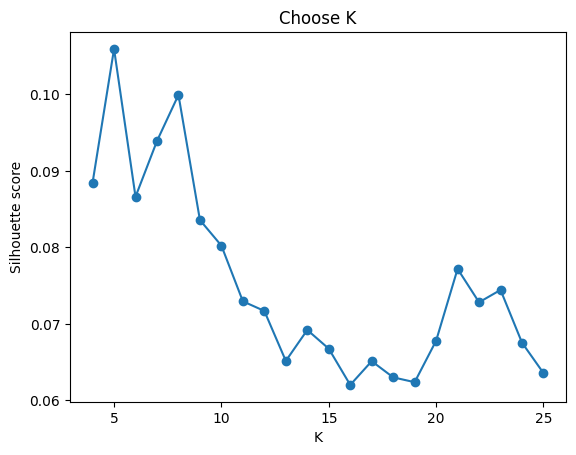

In [30]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(Ks, scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.title("Choose K")
plt.show()

In [31]:
K = best_k  # or set manually, e.g. K = 12
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init="auto")
cluster_id = kmeans.fit_predict(X)

import pandas as pd
clusters_df = pd.DataFrame({"clip_id": kept_clip_ids, "cluster_id": cluster_id})
clusters_df.to_csv(OUT_DIR / "clusters.csv", index=False)
clusters_df.head()

,clip_id,cluster_id
0,output000,3
1,output001,3
2,output002,2
3,output003,4
4,output004,4


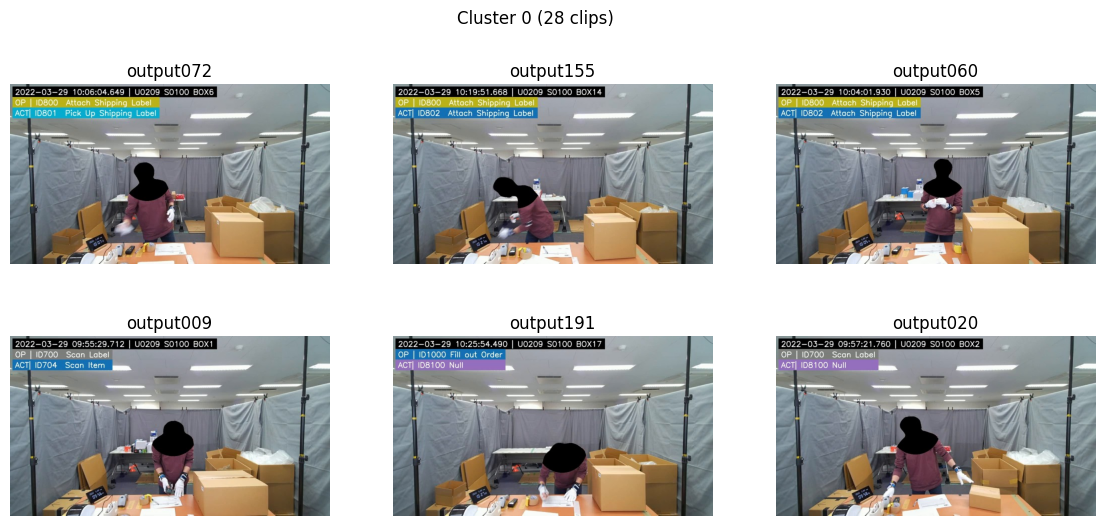

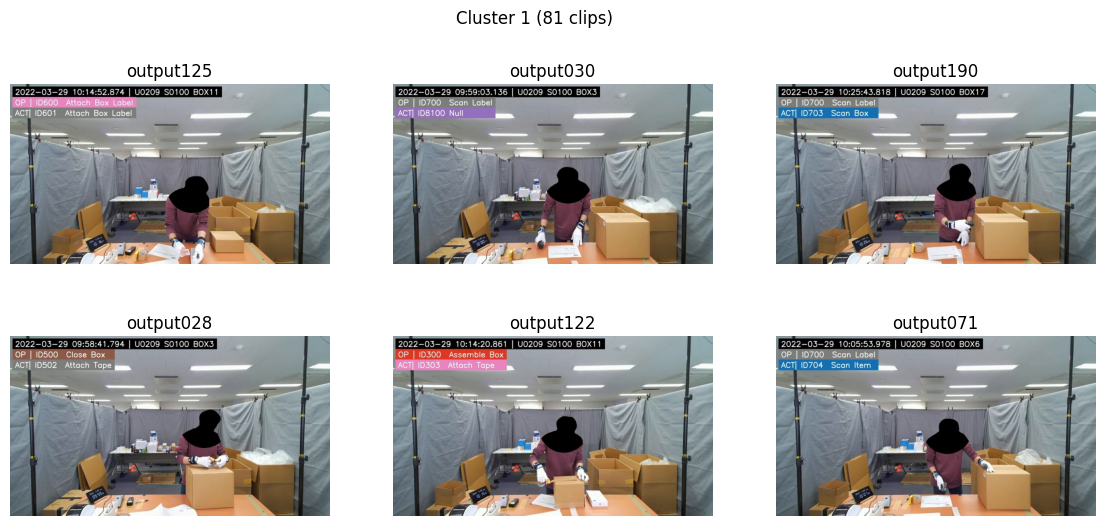

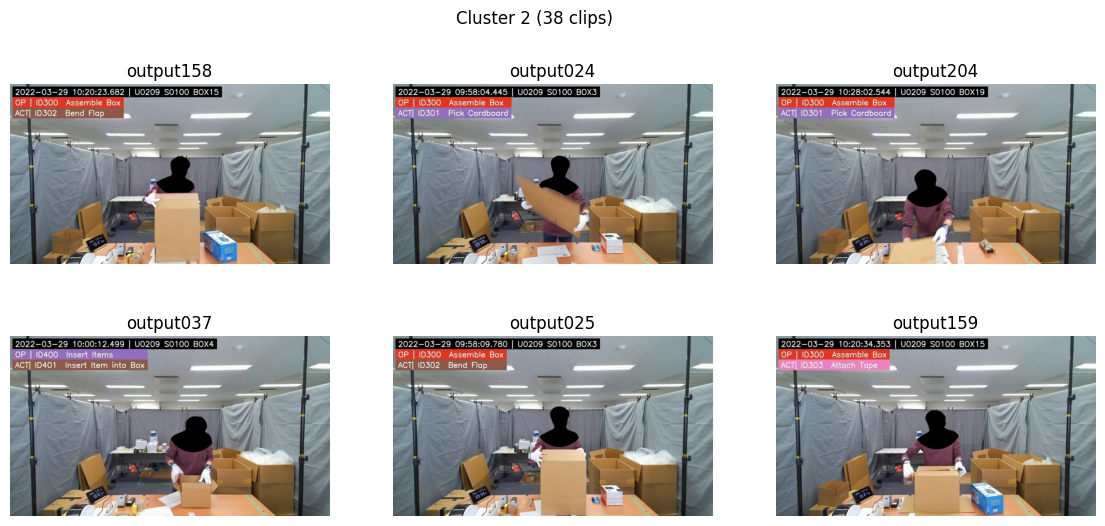

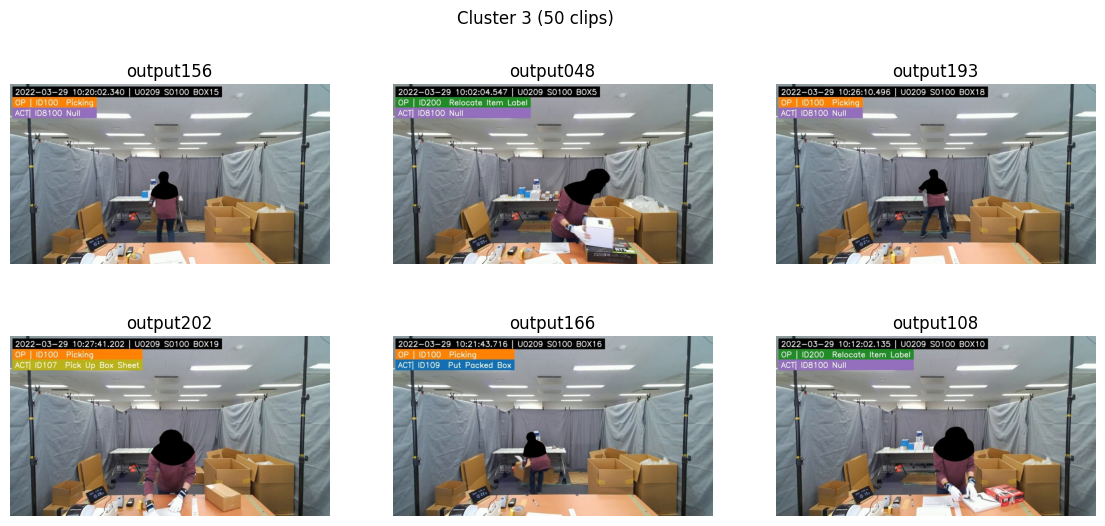

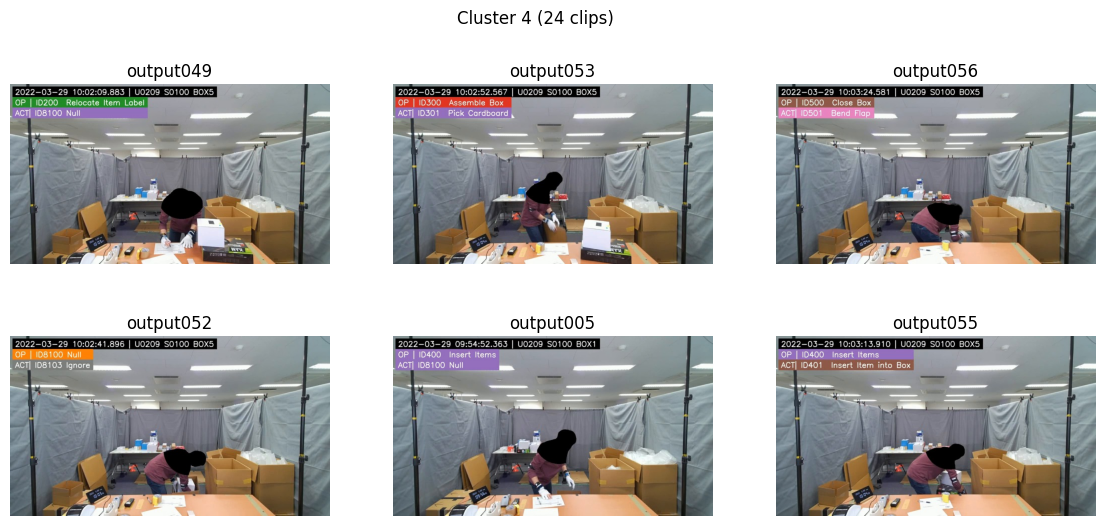

In [32]:
import random
import matplotlib.pyplot as plt

def show_cluster_samples(cluster_idx, n_samples=6):
    members = clusters_df[clusters_df.cluster_id == cluster_idx]["clip_id"].tolist()
    if not members:
        print("empty cluster", cluster_idx); return
    picks = random.sample(members, k=min(n_samples, len(members)))

    # show first frame of each picked clip (you can change frame number)
    plt.figure(figsize=(14, 6))
    for i, cid in enumerate(picks, 1):
        img_path = sorted((FRAMES_DIR / cid).glob("*.jpg"))[0]
        img = Image.open(img_path).convert("RGB")
        ax = plt.subplot(2, (n_samples+1)//2, i)
        ax.imshow(img)
        ax.set_title(cid)
        ax.axis("off")
    plt.suptitle(f"Cluster {cluster_idx} ({len(members)} clips)")
    plt.show()

for c in range(K):
    show_cluster_samples(c, n_samples=6)

In [34]:
# Example mapping (YOU will fill these names)
cluster_to_label = {
    0: "Attach",
    1: "Scan",
    2: "Assemble",
    3: "Picking",
    4: "Null",
}

# Apply mapping
clusters_df["dominant_operation"] = clusters_df["cluster_id"].map(cluster_to_label).fillna("Unknown")

# Optional: per-clip overrides if a few are wrong
overrides = {
    # "output037": "Pick",
}
clusters_df["dominant_operation"] = clusters_df.apply(
    lambda r: overrides.get(r["clip_id"], r["dominant_operation"]), axis=1
)

labels_csv_path = OUT_DIR / "labels.csv"
clusters_df[["clip_id", "dominant_operation"]].to_csv(labels_csv_path, index=False)
print("Saved:", labels_csv_path)
clusters_df[["clip_id","cluster_id","dominant_operation"]].head(200)

Saved: /content/labels.csv


,clip_id,cluster_id,dominant_operation
0,output000,3,Picking
1,output001,3,Picking
2,output002,2,Assemble
3,output003,4,Null
4,output004,4,Null
...,...,...,...
195,output195,1,Scan
196,output196,1,Scan
197,output197,1,Scan
198,output198,1,Scan
